# Correlation Metrics for ROI of each Participant

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
path_dataframe = '/content/drive/MyDrive/Colab Notebooks/Brain_Stim_ANN/data/dataframe/'

In [4]:
import os
import pandas as pd
import numpy as np
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

# --- Load data (adapt to your path if different)
df = pd.read_csv(os.path.join(path_dataframe, "dataframe_with_perm.csv"))
df['predictability'] = df['predictability']**2
#df['responsiveness'] = df['responsiveness']**2

# Make sure sid is treated as categorical
df['sid'] = df['sid'].astype('category')

# --- DIFFERENTIATE VARIABLES WITH AND WITHOUT "perm" ---
perm_cols = [c for c in df.columns if 'perm' in c.lower()]
nonperm_cols = [c for c in df.columns if c not in perm_cols]

print(f"Columns WITH 'perm' ({len(perm_cols)}):")
#print(perm_cols)
print("\nColumns WITHOUT 'perm' ({len(nonperm_cols)}):")
#print(nonperm_cols)

# Subset without perm:
numeric_cols = df[nonperm_cols].select_dtypes(include=[np.number]).columns.tolist()

for col in ['roi', 'rsn_id']:
    if col in numeric_cols:
        numeric_cols.remove(col)

print(f"Using {len(numeric_cols)} numeric variables:")
print(numeric_cols)

# 2) Drop rows with any NaNs in these variables (you can be more permissive if needed)
sub = df[['sid'] + numeric_cols].dropna().copy()

# 3) Subject-centering: subtract subject mean for each variable
sub_centered = sub.copy()
for col in numeric_cols:
    sub_centered[col] = sub_centered[col] - \
        sub_centered.groupby('sid', observed=False)[col].transform('mean')

# We now have within-subject fluctuations only
X = sub_centered[numeric_cols]

# 4) Pairwise Spearman's correlation matrix (within-subject)
R = X.corr(method='spearman')

# 5) Approximate p-values for each r (standard formula, no cluster correction)
n_eff = X.shape[0]  # number of rows after dropping NaNs
P = pd.DataFrame(np.ones_like(R), columns=R.columns, index=R.index)

# avoid division by zero
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        if i == j:
            continue
        r = R.iat[i, j]
        if np.isfinite(r) and abs(r) < 1:
            t = r * np.sqrt((n_eff - 2) / (1 - r**2))
            from scipy.stats import t as tdist
            p = 2 * (1 - tdist.cdf(abs(t), df=n_eff - 2))
            P.iat[i, j] = p

# 6) FDR correction
p_flat = P.values.flatten()
_, p_fdr_flat, _, _ = multipletests(p_flat, method='fdr_bh')
P_fdr = pd.DataFrame(p_fdr_flat.reshape(P.shape), columns=P.columns, index=P.index)

print("Done! Within-subject correlation matrix computed.")

Columns WITH 'perm' (26000):

Columns WITHOUT 'perm' ({len(nonperm_cols)}):
Using 25 numeric variables:
['responsiveness', 'predictability', 'evoked_energy', 'principal_gradient', '5HT4_sb20_hc59_beliveau.csv', '5HT6_gsk_hc30_radhakrishnan.csv', 'A4B2_flubatine_hc30_hillmer.csv', 'H3_cban_hc8_gallezot.csv', 'M1_lsn_hc24_naganawa.csv', 'NMDA_ge179_hc29_galovic.csv', '5HT1a', '5HT1b', '5HT2a', '5HTT', 'CB1', 'D1', 'D2', 'DAT', 'GABA', 'MU', 'NAT', 'Vacht', 'mGluR5', 'SC_strength', 'SC_centrality']
Done! Within-subject correlation matrix computed.


In [5]:
np.sum(np.where(df['responsiveness']<0))
#responsiveness+ (sum of effective connectivity positives)
#responsiveness- (sum of effective connectivity negatives)

np.int64(0)

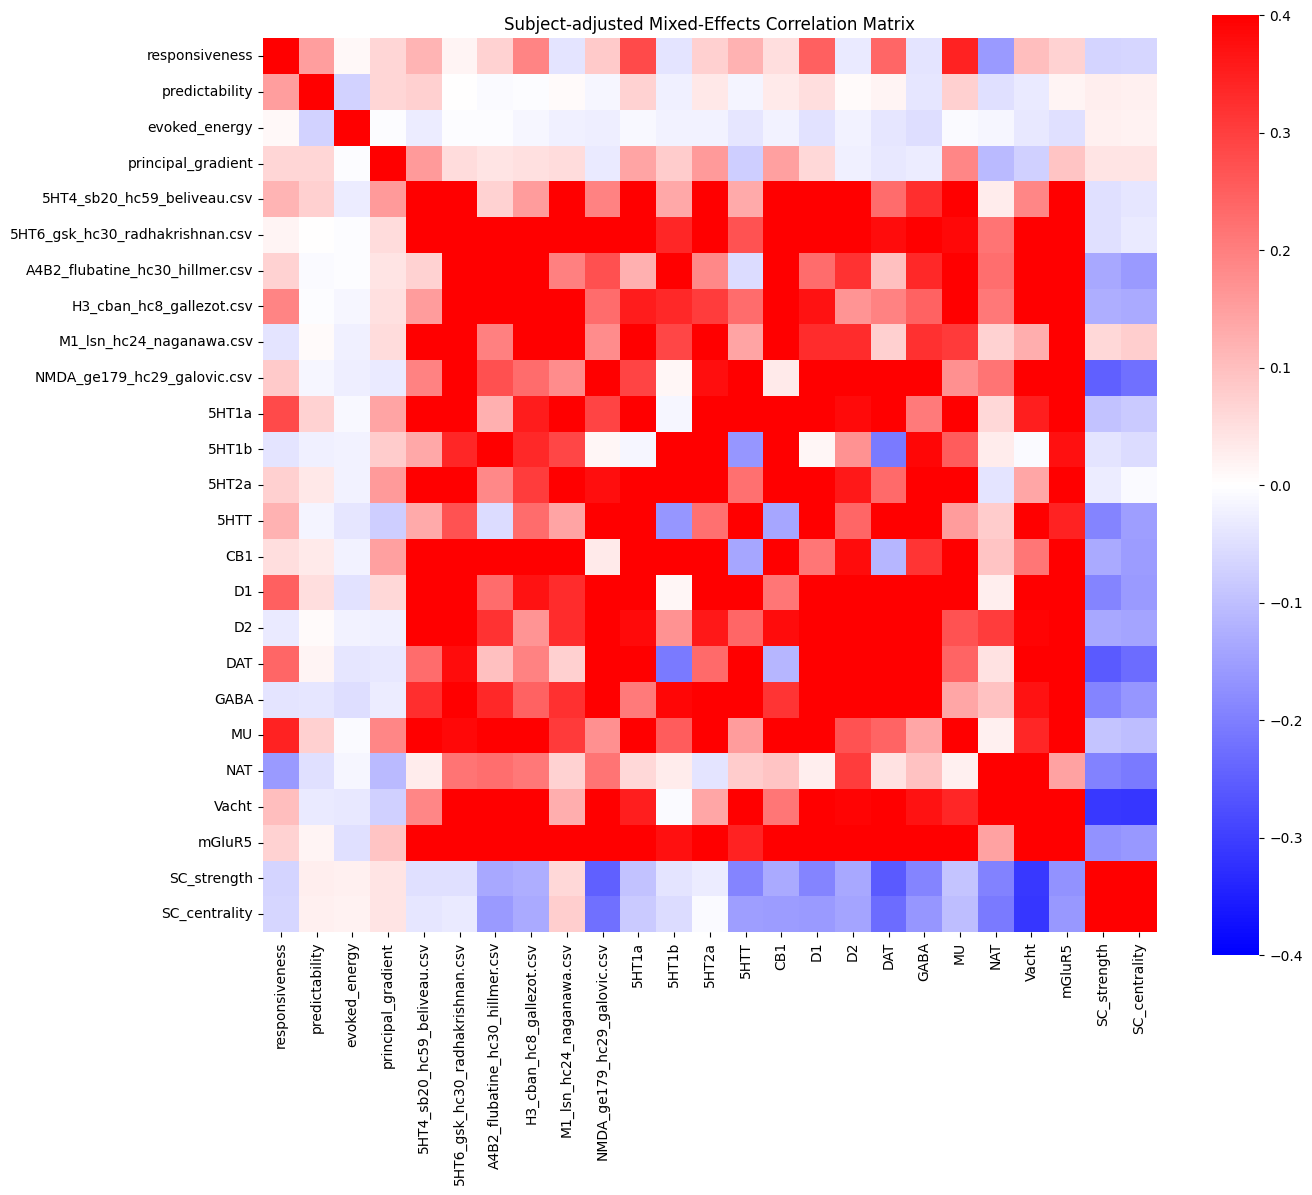

In [7]:
plt.figure(figsize=(14, 12))
sns.heatmap(R, cmap="bwr", center=0, square=True, vmin = -0.4, vmax= 0.4 )
plt.title("Subject-adjusted Mixed-Effects Correlation Matrix")
plt.tight_layout()
plt.show()

In [8]:
def plot_pair(x, y,
              use_centered=True,
              method='pearson',
              use_fdr=False,              # <==== NEW
              save=False,
              outdir="plots_pairs"):

    data = sub_centered if use_centered else sub
    xy = data[[x, y]].dropna()
    X = xy[x].values
    Y = xy[y].values

    # raw p-values
    if method == 'spearman':
        r, p = spearmanr(X, Y)
        r_label = "ρ"
    else:
        r, p = pearsonr(X, Y)
        r_label = "r"

    # FDR correction display
    if use_fdr:
        p_display = P_fdr.loc[x, y]
    else:
        p_display = p

    # Plot
    plt.figure(figsize=(5, 4))
    sns.regplot(data=xy, x=x, y=y,
                scatter_kws={'alpha': 0.4, 's': 10},
                line_kws={'linewidth': 2})

    title = f"{y} vs {x}\n{r_label} = {r:.2f}, p = {p_display:.2e}"
    if use_centered:
        title = "within-subject " + title
    if method == 'spearman':
        title = title.replace("vs", "(Spearman) vs")
    plt.title(title)
    plt.tight_layout()

    if save:
        os.makedirs(outdir, exist_ok=True)
        fname = f"{outdir}/{y}_vs_{x}_{method}.png".replace("/", "_")
        plt.savefig(fname, dpi=300)
    plt.show()



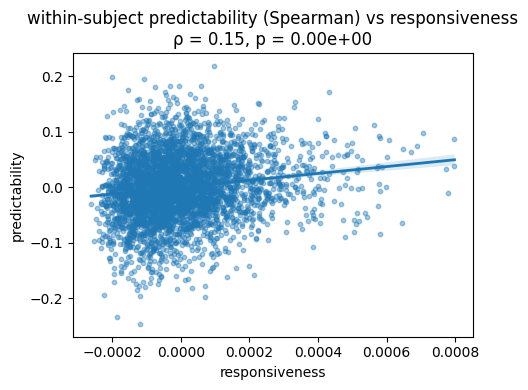

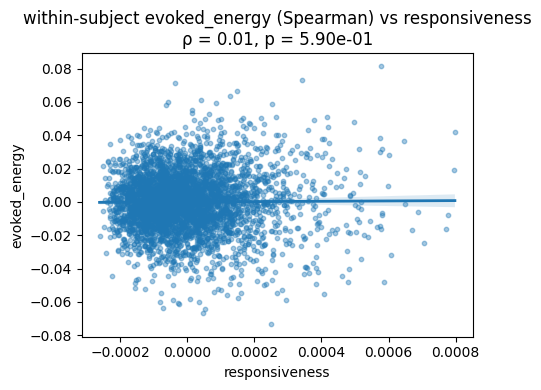

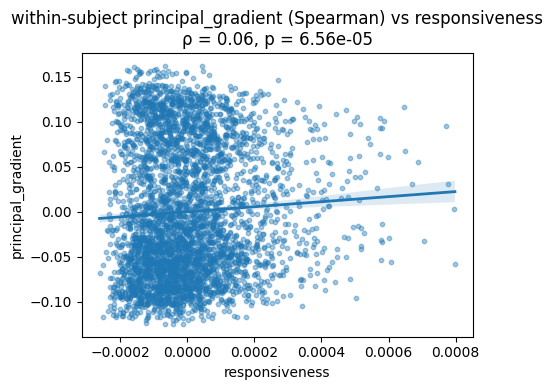

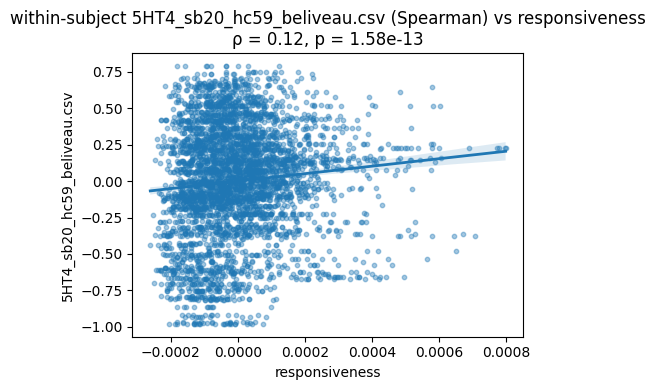

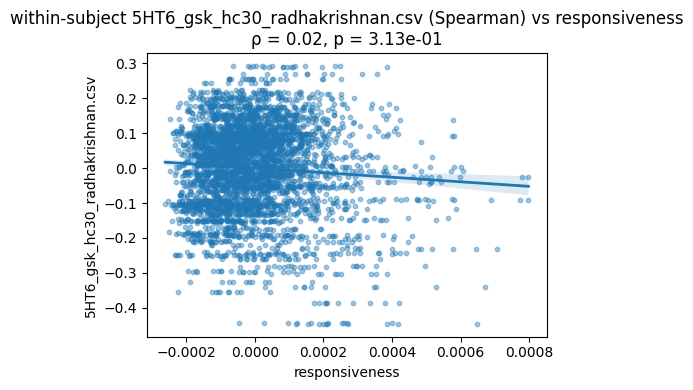

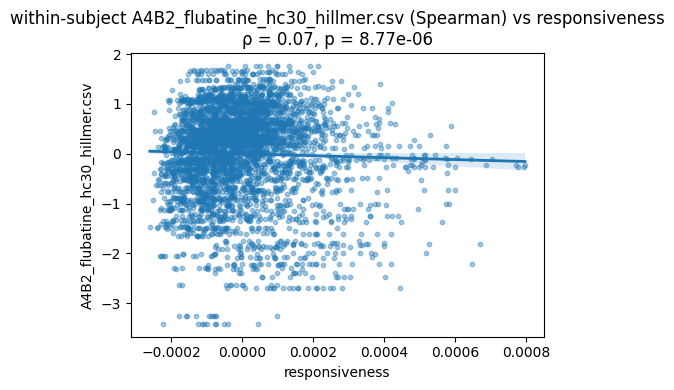

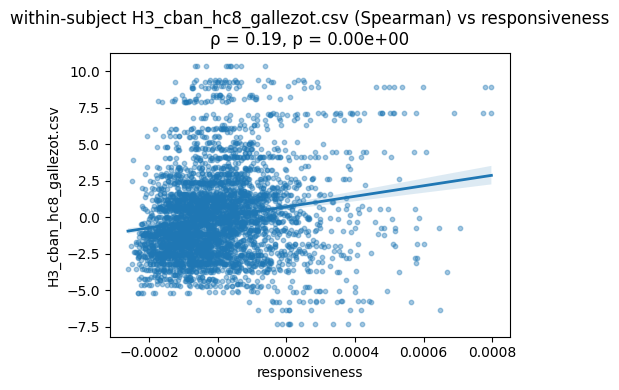

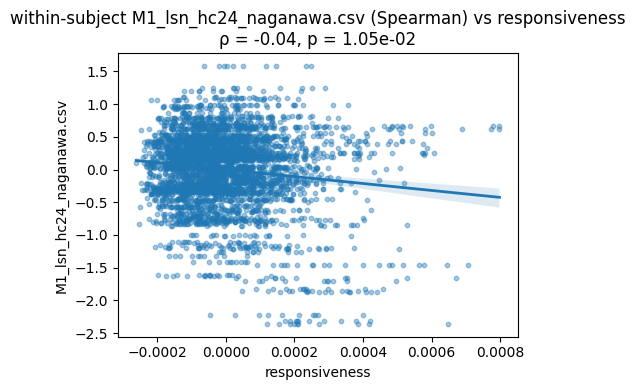

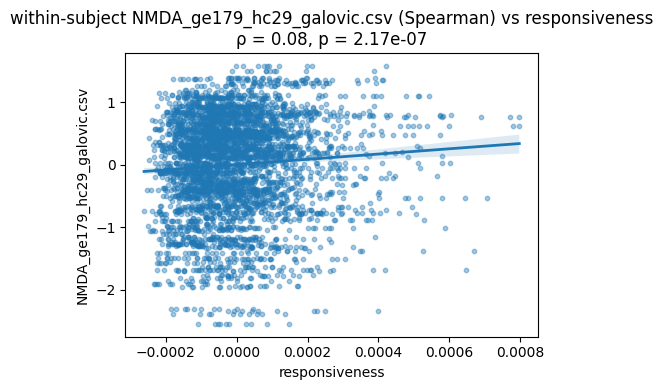

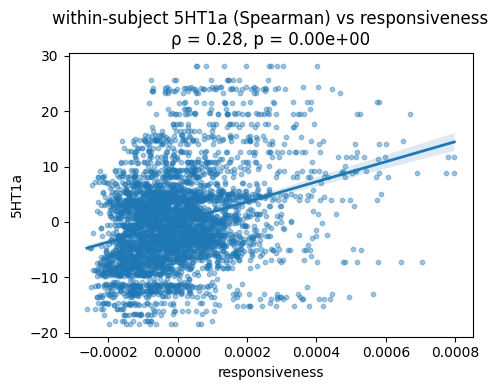

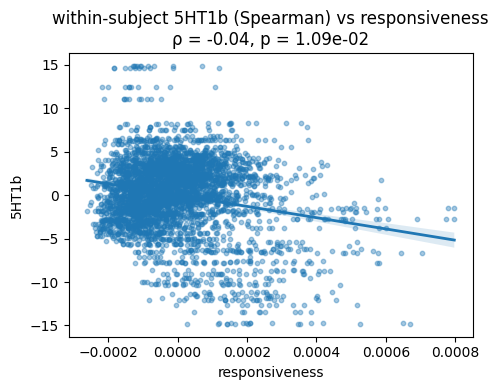

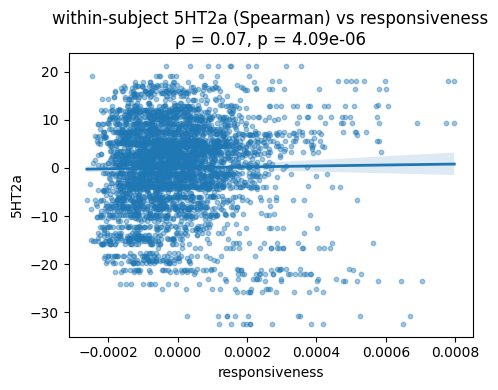

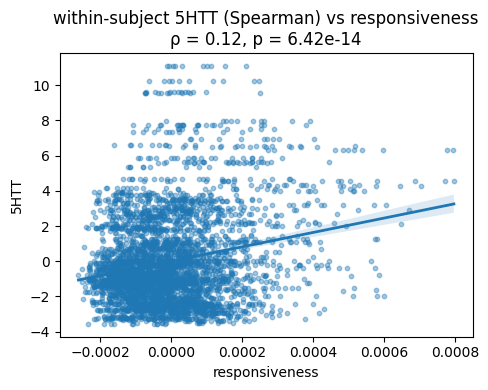

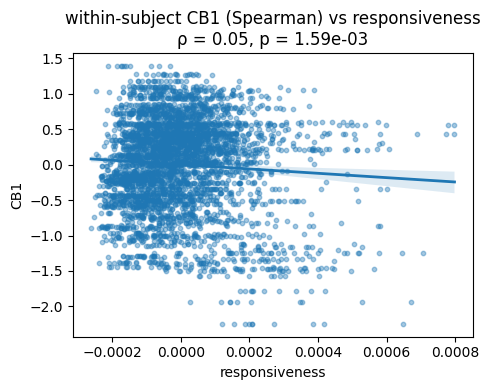

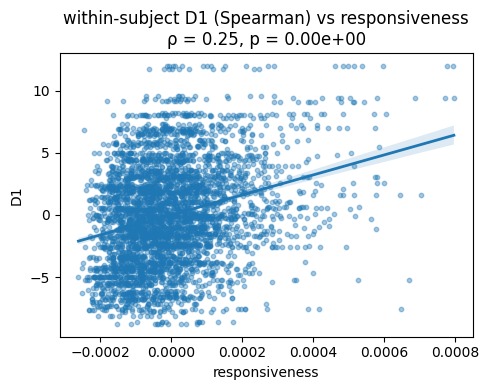

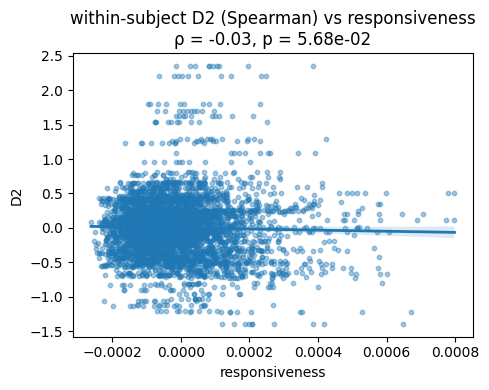

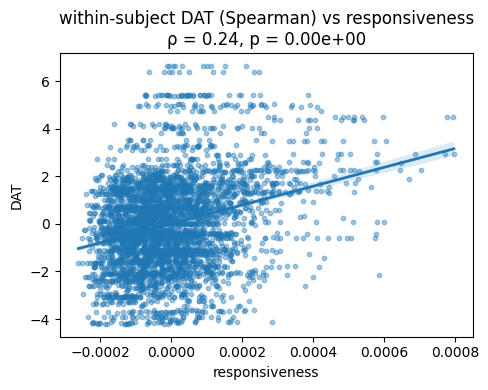

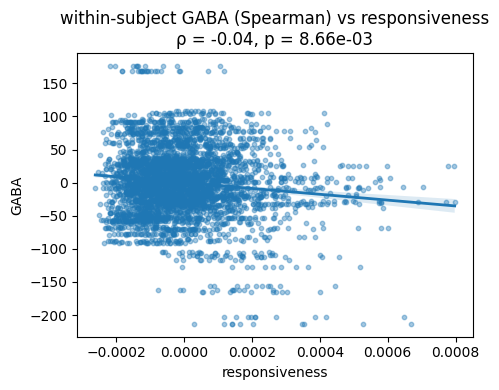

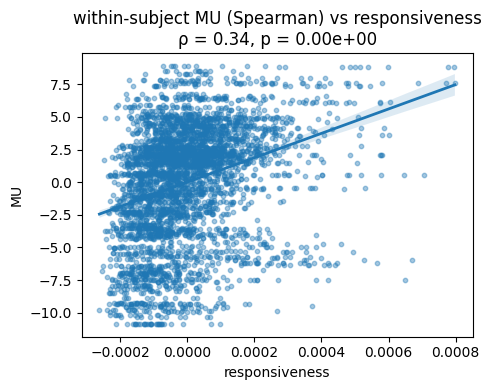

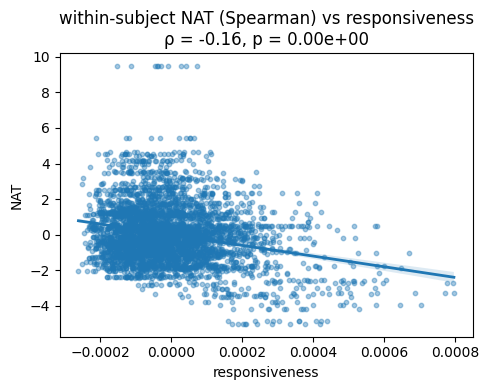

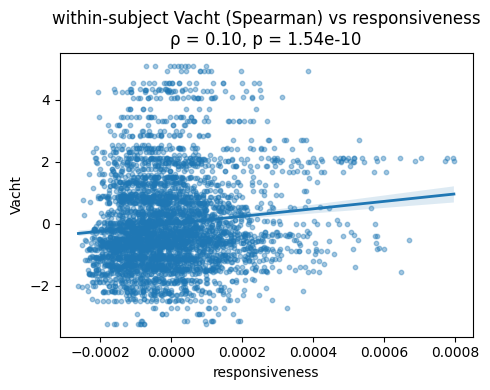

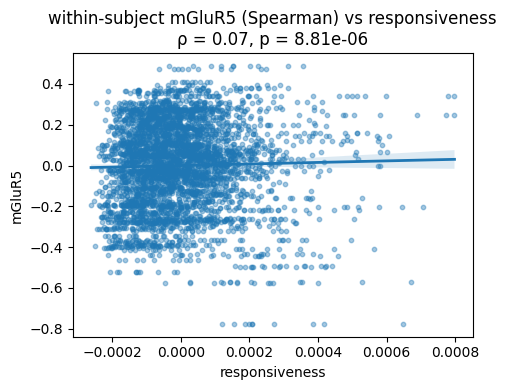

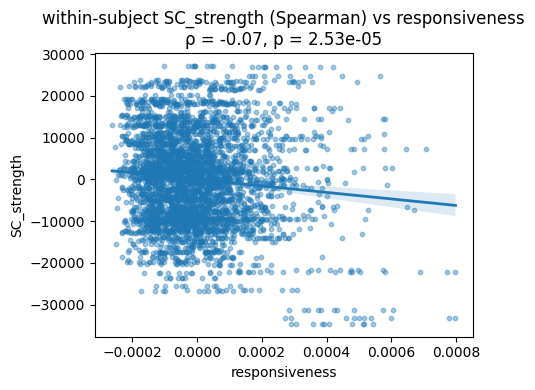

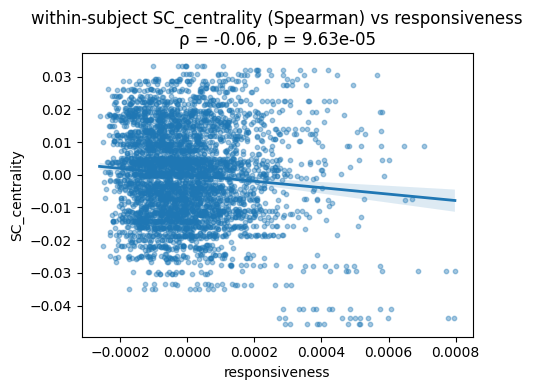

In [9]:
base_var = "responsiveness"  # change

for y in numeric_cols:
    if y == base_var:
        continue
    plot_pair(base_var, y, use_centered=True, use_fdr = True, method = 'spearman',save=False )


**Interpretation**: Responsiveness correlates with many receptor maps, predictability does not.

Responsivness is strongly shaped by neuromodulation which is extremly consistent and says that responsivness reflecsocal excitability, gain and inhibitory/neuromodulatory control. Responsiveness is a biological susceptibility marker.

Predictability does not couple to neuromodulators. It reflects network-level integrative architecture not local receptor densities.

Therefore:

**1 Responsiveness**: Reflects local gain, excitability and neuromodulatory regulation.

**2 Predictability**: Reflect large-scale network structure and integration, not receptor driven.


This reveals a clear dissociation between local reactivity and global forecastability in cortical dynamics.

# Correlations doing the average of Participants

In [10]:
# Remove ID-like numeric columns from those to be averaged
for col in ['roi', 'rsn_id', 'sid']:
    if col in numeric_cols:
        numeric_cols.remove(col)

print("Averaging these numeric columns:")
print(numeric_cols)

# --- One value per ROI across subjects ---
df_roi = (
    df.groupby(['roi', 'rsn_id'], observed=False)[numeric_cols]
      .mean()
      .reset_index()
)

print(df_roi.shape)

Averaging these numeric columns:
['responsiveness', 'predictability', 'evoked_energy', 'principal_gradient', '5HT4_sb20_hc59_beliveau.csv', '5HT6_gsk_hc30_radhakrishnan.csv', 'A4B2_flubatine_hc30_hillmer.csv', 'H3_cban_hc8_gallezot.csv', 'M1_lsn_hc24_naganawa.csv', 'NMDA_ge179_hc29_galovic.csv', '5HT1a', '5HT1b', '5HT2a', '5HTT', 'CB1', 'D1', 'D2', 'DAT', 'GABA', 'MU', 'NAT', 'Vacht', 'mGluR5', 'SC_strength', 'SC_centrality']
(400, 27)


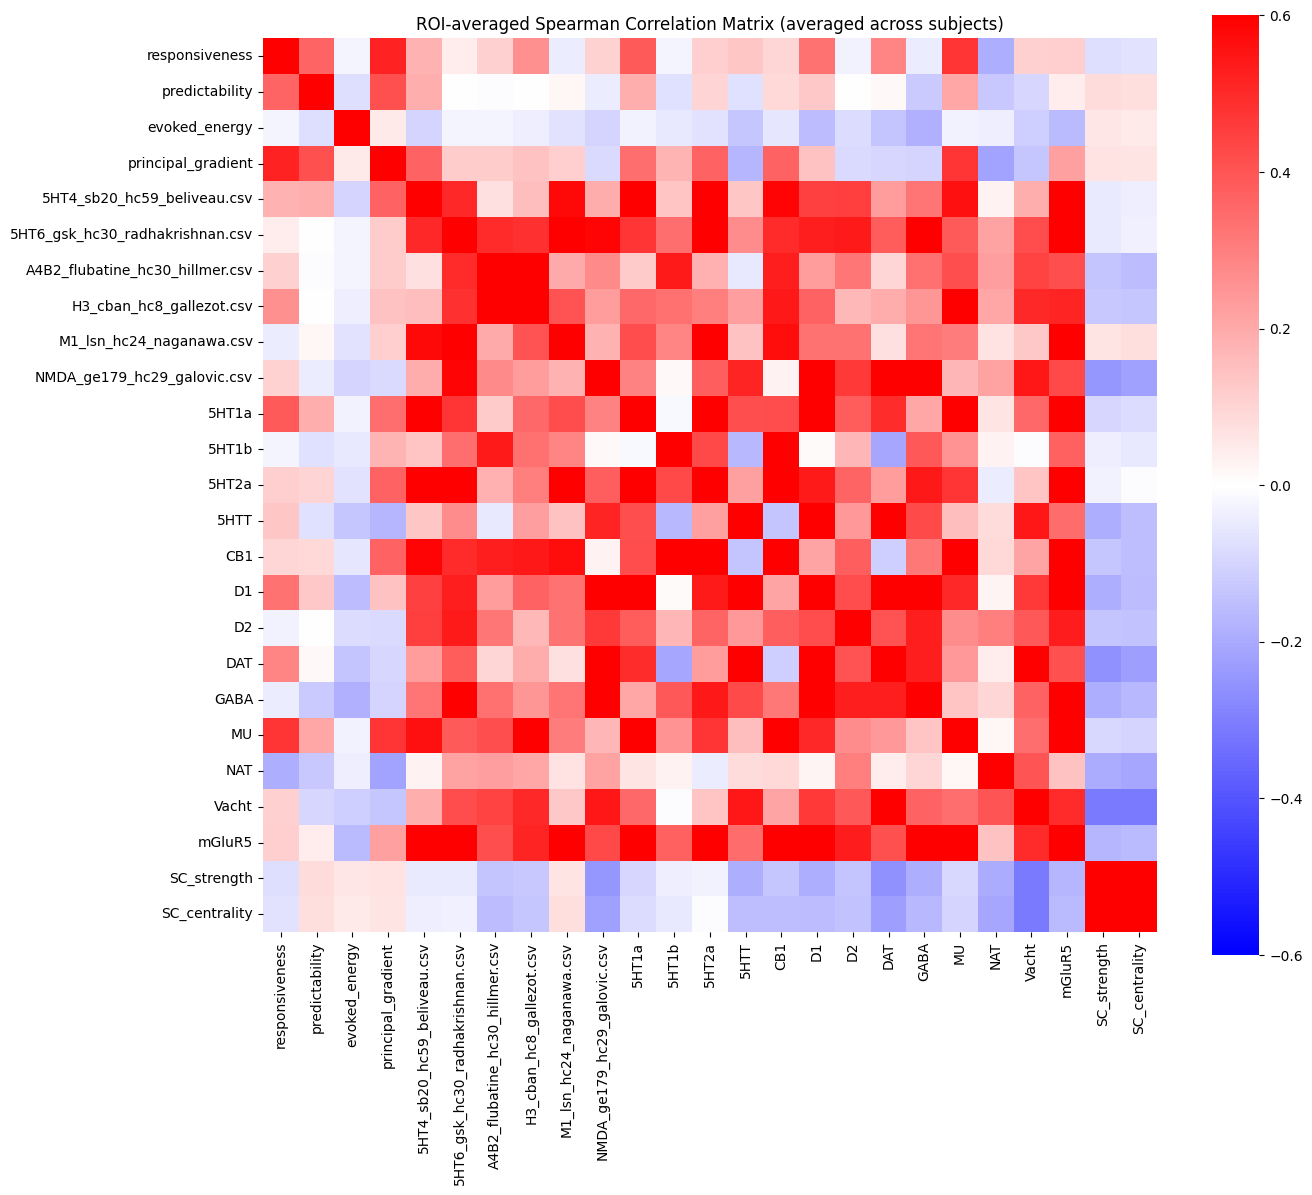

In [11]:
# 2) One value per ROI across subjects
df_roi = (
    df.groupby(['roi', 'rsn_id'], observed=False)[numeric_cols]
      .mean()
      .reset_index()
)

# 3) Build matrix X = ROI × metrics for correlation
X = df_roi[numeric_cols].dropna().copy()

# 4) Pairwise Spearman's correlation matrix (across ROIs)
R = X.corr(method='spearman')

# 5) Approximate p-values for each r (standard formula, no cluster correction)
n_eff = X.shape[0]  # now: number of ROIs
P = pd.DataFrame(np.ones_like(R), columns=R.columns, index=R.index)

for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        if i == j:
            continue
        r = R.iat[i, j]
        if np.isfinite(r) and abs(r) < 1:
            t = r * np.sqrt((n_eff - 2) / (1 - r**2))
            p = 2 * (1 - tdist.cdf(abs(t), df=n_eff - 2))
            P.iat[i, j] = p

# 6) FDR correction on correlations
p_flat = P.values.flatten()
_, p_fdr_flat, _, _ = multipletests(p_flat, method='fdr_bh')
P_fdr = pd.DataFrame(p_fdr_flat.reshape(P.shape), columns=P.columns, index=P.index)

# 7) Heatmap of ROI-averaged correlation matrix
plt.figure(figsize=(14, 12))
sns.heatmap(R, cmap="bwr", center=0, square=True, vmin=-0.6, vmax=0.6)
plt.title("ROI-averaged Spearman Correlation Matrix (averaged across subjects)")
plt.tight_layout()
plt.show()


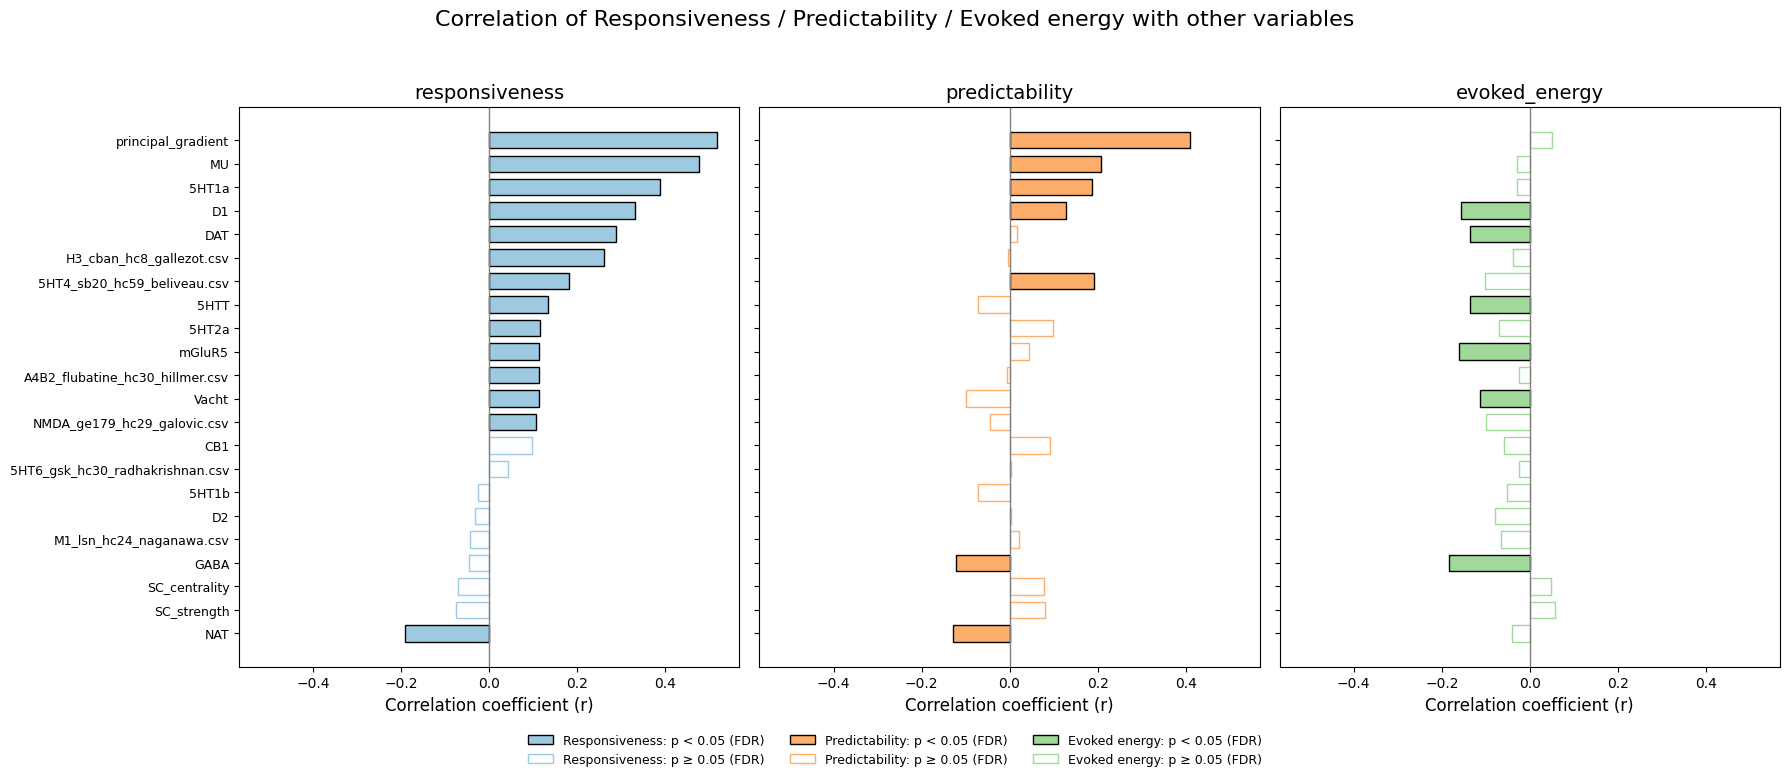

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# === Targets (usa los nombres exactos de R/P_fdr) ===
target_vars = ["responsiveness", "predictability", "evoked_energy"]

# Chequeo estricto: que existan en columnas de R y P_fdr
missing_R = [t for t in target_vars if t not in R.columns]
missing_P = [t for t in target_vars if t not in P_fdr.columns]
if missing_R or missing_P:
    raise ValueError(
        "Missing targets:\n"
        f"  In R.columns: {missing_R}\n"
        f"  In P_fdr.columns: {missing_P}"
    )

# Colores: uno por target (mismo orden que target_vars)
colors = ["#9ecae1", "#fdae6b", "#a1d99b"]  # azul, naranja, verde
p_thresh = 0.05

# Predictores: todo menos los targets
predictors = [c for c in R.columns if c not in target_vars]

# Orden único basado en la correlación con el primer target (responsiveness)
base_target = target_vars[0]
base_r = R.loc[predictors, base_target]
order = np.argsort(base_r.values)  # usa [::-1] si quieres descendente
ordered_vars = np.array(predictors)[order]

# --- Precalcula límites globales para compartir eje X ---
all_r = R.loc[ordered_vars, target_vars].to_numpy()
global_max_abs = np.nanmax(np.abs(all_r))
margin = 0.05
xlim = (-global_max_abs - margin, global_max_abs + margin)

# Figura: tres paneles, compartiendo eje Y
fig, axes = plt.subplots(1, len(target_vars), figsize=(18, 8), sharey=True)
if len(target_vars) == 1:
    axes = [axes]

for ax, target, facecolor in zip(axes, target_vars, colors):

    r_vals = R.loc[ordered_vars, target]
    p_vals = P_fdr.loc[ordered_vars, target]

    y_pos = np.arange(len(ordered_vars))
    sig = p_vals < p_thresh

    ax.barh(y_pos[sig],  r_vals[sig],  color=facecolor, edgecolor="black", height=0.7)
    ax.barh(y_pos[~sig], r_vals[~sig], color="none", edgecolor=facecolor, height=0.7)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(ordered_vars, fontsize=9)

    # mismo eje X en los 3
    ax.set_xlim(*xlim)
    ax.axvline(0, color="gray", linewidth=1)

    ax.set_title(target, fontsize=14)
    ax.set_xlabel("Correlation coefficient (r)", fontsize=12)

fig.suptitle(
    "Correlation of Responsiveness / Predictability / Evoked energy with other variables",
    fontsize=16
)

legend_handles = [
    Patch(facecolor=colors[0], edgecolor="black", label="Responsiveness: p < 0.05 (FDR)"),
    Patch(facecolor="none", edgecolor=colors[0], label="Responsiveness: p ≥ 0.05 (FDR)"),
    Patch(facecolor=colors[1], edgecolor="black", label="Predictability: p < 0.05 (FDR)"),
    Patch(facecolor="none", edgecolor=colors[1], label="Predictability: p ≥ 0.05 (FDR)"),
    Patch(facecolor=colors[2], edgecolor="black", label="Evoked energy: p < 0.05 (FDR)"),
    Patch(facecolor="none", edgecolor=colors[2], label="Evoked energy: p ≥ 0.05 (FDR)"),
]
fig.legend(handles=legend_handles,
           loc="lower center",
           bbox_to_anchor=(0.5, 0.02),
           ncol=3,
           frameon=False,
           fontsize=9)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()

# Permutation Maps

In [26]:
import pandas as pd
import numpy as np
from statsmodels.stats.multitest import multipletests
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

# --- assume df and perm_cols already defined ---

real_receptor = "GABA"
target = 'evoked_energy'

# 1) Keep only permutation columns containing "5HT1A" (case-insensitive)
cols_receptor = [c for c in perm_cols if real_receptor.lower() in c.lower()]
print("Found perm cols:", len(cols_receptor))

# 2) Build the list of numeric columns we want in the *subject-level* analysis:
#    all 5HT1A perm columns + responsiveness
numeric_cols = cols_receptor + [target]

# (optional) safety check: keep only numeric
numeric_cols = df[numeric_cols].select_dtypes(include=[np.number]).columns.tolist()

print(f"Using {len(numeric_cols)} numeric variables:")
#print(numeric_cols)

#
df_roi = df.groupby("roi", observed=False)[target].mean().reset_index()
df_merge = df[["roi"] + cols_receptor].drop_duplicates(subset="roi")
df_analysis = df_merge.merge(df_roi, on="roi", how="inner")

X = df_analysis[numeric_cols].dropna().copy()
# 6) Compute Spearman correlation + p-value between
#    responsiveness and EACH 5HT1A permutation column
results = []

for col in cols_receptor:
    if col not in X.columns:
        continue  # por si alguna no era numérica y se cayó antes
    rho, p = spearmanr(X[target], X[col])
    results.append({'perm_col': col, 'rho': rho, 'p': p})

res_df = pd.DataFrame(results)
print(res_df.head())


Found perm cols: 2000
Using 2001 numeric variables:
         perm_col       rho         p
0  GABA_perm_0000  0.092144  0.065618
1  GABA_perm_0001 -0.028531  0.569394
2  GABA_perm_0002  0.114307  0.022226
3  GABA_perm_0003 -0.004611  0.926758
4  GABA_perm_0004  0.026771  0.593449


Real receptor GABA: rho = -0.1830, p(FDR) = 0.0004408
Permutation p-value (two-sided): 0.002499


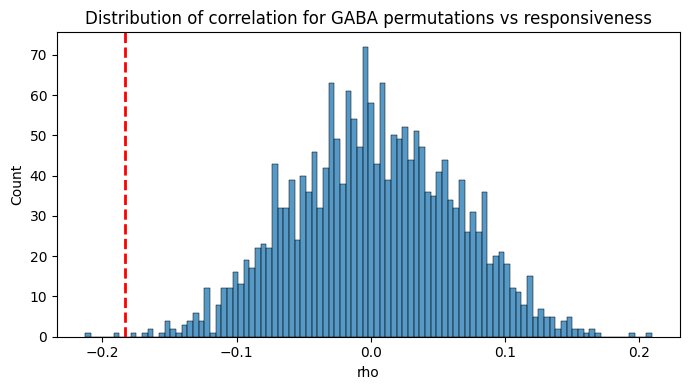

In [27]:
# 8) Plot histogram of p-values (or FDR-corrected p-values) for 5HT1A perms
rho_real = R.loc[real_receptor, target]
p_real  = P_fdr.loc[real_receptor, target]
print(f"Real receptor {real_receptor}: rho = {rho_real:.4f}, p(FDR) = {p_real:.4g}")

# Compute permutation p-value
r_nulls = res_df['rho'].values
r_nulls = np.asarray(r_nulls)
r_nulls = r_nulls[np.isfinite(r_nulls)]
N = len(r_nulls)

# Two-sided:
p_perm = (np.sum(np.abs(r_nulls) >= np.abs(rho_real)) + 1) / (N + 1)

print(f"Permutation p-value (two-sided): {p_perm:.6f}")

plt.figure(figsize=(7, 4))
sns.histplot(r_nulls, bins=100)
plt.xlabel('rho')
plt.ylabel('Count')
plt.title(f"Distribution of correlation for {real_receptor} permutations vs responsiveness")
plt.axvline(rho_real, color='red', linestyle='--', linewidth=2)
plt.tight_layout()
plt.show()